In [ ]:
import numpy as np 

In [2]:
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.1, n_iters=1000):
        self.lr=learning_rate 
        self.lambda_param=lambda_param
        self.n_iters=n_iters
        self.w=None
        self.b=None
    def fit(self,X,y):
        n_samples, n_features= X.shape
        y_=np.where(y<= 0,-1,1)
        self.w=np.zeros(n_features)
        self.b=0
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx]*(np.dot(x_i, self.w)-self.b) >=1
                if condition:
                    self.w -= self.lr*(2* self.lambda_param* self.w)
                else: 
                    self.w -= self.lr*(2*self.lambda_param*self.w -np.dot(x_i, y_[idx]))
                    self.b -= self.lr*y_[idx]
def predict(self, X):
    linear_output =np.dot(X, self.w)-self.b
    return np.sign(linear_output)


        

In [5]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
X, y=make_blobs(n_samples=100, centers=2, random_state=42)
y=np.where(y== 0,-1,1)


In [6]:
model= SVM()
model.fit(X,y)

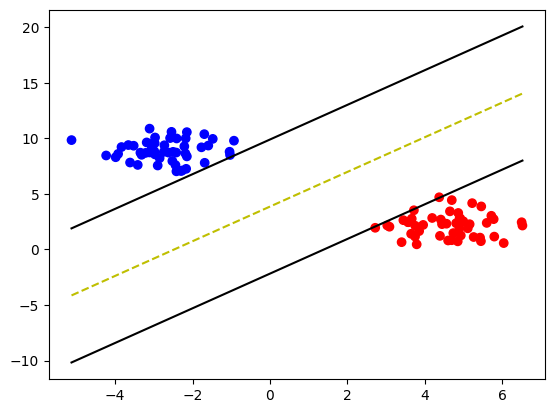

In [7]:
def plot_decision_boundary(X, y, model):
    def get_hyperplane_value(x, w, b, offset):
        return (-w[0] * x + b + offset) / w[1]

    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)

    plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')

    x0_1 = np.amin(X[:,0])
    x0_2 = np.amax(X[:,0])

    x1_1 = get_hyperplane_value(x0_1, model.w, model.b, 0)
    x1_2 = get_hyperplane_value(x0_2, model.w, model.b, 0)

    x1_1_m = get_hyperplane_value(x0_1, model.w, model.b, -1)
    x1_2_m = get_hyperplane_value(x0_2, model.w, model.b, -1)

    x1_1_p = get_hyperplane_value(x0_1, model.w, model.b, 1)
    x1_2_p = get_hyperplane_value(x0_2, model.w, model.b, 1)

    ax.plot([x0_1, x0_2], [x1_1, x1_2], 'y--')
    ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], 'k')
    ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], 'k')

    plt.show()

plot_decision_boundary(X, y, model)
